# Visualizing data

[Download notebook](notebooks/08_visualizing_data.ipynb).

In this chapter, we first discuss the general principles behind choosing
the right chart type, and then learn how to create plots in Python using
`matplotlib`.

## Choosing the right chart

Before writing any code, it is worth thinking about what kind of chart
best conveys your message. A useful framework (following Zelazny, [*Wie
aus Zahlen Bilder
werden*](https://link.springer.com/book/10.1007/978-3-658-07452-4))
proceeds in three steps:

1.  **What is your message?** The chart form should not be chosen based
    on the data alone, but on what you want to say about it. The same
    table of numbers can lead to very different charts depending on the
    message. A good chart title states the message, not just the topic —
    for example, “Revenue has doubled since January” instead of “Revenue
    overview”.

2.  **What type of comparison does your message involve?** Every message
    implies one of five basic comparison types:

    - **Structure**: What share does each part have of the whole?
      Keywords: *share, percentage, proportion*. Example: “Product A
      accounts for 70% of total revenue.”
    - **Ranking**: How do items compare in size or order? Keywords:
      *larger than, smaller than, equal*. Example: “Region South has the
      highest sales.”
    - **Time series**: How does a quantity change over time? Keywords:
      *increase, decrease, trend, fluctuation*. Example: “Revenue has
      grown steadily since January.”
    - **Frequency distribution**: How are values distributed across
      ranges? Keywords: *concentration, distribution, range*. Example:
      “Most orders fall between 1,000 and 2,000 euros.”
    - **Correlation**: Is there a relationship between two variables?
      Keywords: *relates to, follows, independent of*. Example: “There
      is no connection between experience and sales success.”

3.  **Which chart form fits the comparison type?** There are five basic
    chart forms, and each is best suited for certain comparison types:

    - **Pie chart** (*Kreisdiagramm*): Shows parts of a whole. Best for
      **structure** comparisons, but use sparingly — bar charts are
      almost always more readable. Limit to at most 5% of the charts in
      a report.
    - **Bar chart** (*Balkendiagramm*, horizontal bars): Extremely
      versatile. Best for **structure** and **ranking** comparisons.
      Should make up about 25% of charts.
    - **Column chart** (*Säulendiagramm*, vertical bars): The workhorse
      for **time series** and **frequency distributions** when the
      number of data points is small (up to about six).
    - **Line chart** (*Kurvendiagramm*): Best for **time series** and
      **frequency distributions** with many data points. Together with
      column charts, these should cover about half of all charts.
    - **Scatter plot** (*Punktediagramm*): Best for **correlation**
      comparisons. Also works for time series and frequency
      distributions with very many data points. About 10% of charts.

    Beyond these five basic forms, two additional chart types are
    frequently used in data analysis:

    - **Heatmap**: Displays a matrix of values as a grid of colored
      cells. Useful for **correlation** matrices, confusion matrices, or
      any data with two categorical axes where patterns emerge from
      color intensity.
    - **Error bar plot**: Shows point estimates (e.g., means) together
      with uncertainty ranges (e.g., standard deviations or confidence
      intervals). Common in scientific and statistical contexts,
      especially for **ranking** comparisons where the uncertainty
      matters.

The following matrix (adapted from Zelazny) summarizes which chart form
to use for which comparison type. Each cell contains a small example of
the recommended chart form.

## Plotting with `matplotlib`

The standard plotting library in Python is `matplotlib`. Its `pyplot`
module provides a MATLAB-like interface. Here, `plt` refers to
`matplotlib.pyplot`.

- `plt.figure(figsize=(w, h))`: create a new figure with given size in
  inches.
- `plt.xlabel(...)`, `plt.ylabel(...)`, `plt.title(...)`: axis labels
  and title.
- `plt.legend()`: show legend.
- `plt.show()`: display the figure.
- `fig, axes = plt.subplots(nrows, ncols)`: create a figure with
  multiple subplots.
- `plt.tight_layout()`: automatically adjust spacing between subplots.
- `plt.colorbar()`: add a color bar to the current plot.

When using subplots, each axis object supports the same methods:
`axes.plot()`, `axes.bar()`, `axes.set_title()`, `axes.legend()`, etc.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(0)

## Line plots (`plot`)

A line plot connects data points with straight line segments. It is the
standard chart for **time series** and continuous functions.

- `plt.plot(x, y, label=...)`: line plot.

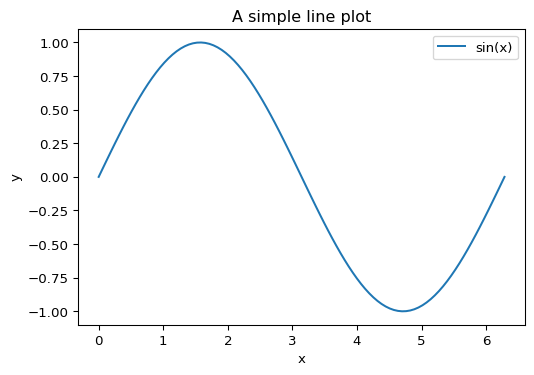

In [3]:
x = np.linspace(0, 2 * np.pi, 100)
y = np.sin(x)

plt.figure(figsize=(6, 4))
plt.plot(x, y, label="sin(x)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("A simple line plot")
plt.legend()
plt.show()

## Scatter plots (`scatter`)

A scatter plot shows individual data points without connecting them. It
is the primary chart for **correlation** comparisons.

- `plt.scatter(x, y, s=..., label=...)`: scatter plot (`s` is marker
  size).

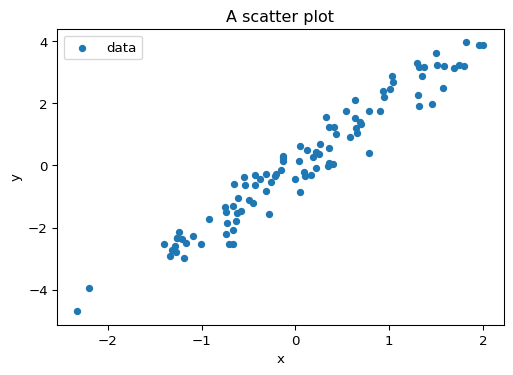

In [4]:
x = rng.normal(size=100)
y = 2 * x + 0.5 * rng.normal(size=100)

plt.figure(figsize=(6, 4))
plt.scatter(x, y, s=20, label="data")
plt.xlabel("x")
plt.ylabel("y")
plt.title("A scatter plot")
plt.legend()
plt.show()

## Pie charts (`pie`)

A pie chart shows parts of a whole. Use sparingly — bar charts are
almost always more readable.

- `plt.pie(values, labels=...)`: pie chart. Use `autopct` to display
  percentages.

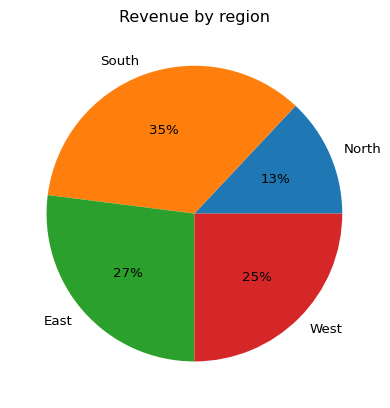

In [5]:
labels = ["North", "South", "East", "West"]
values = [13, 35, 27, 25]

plt.figure(figsize=(5, 5))
plt.pie(values, labels=labels, autopct="%1.0f%%")
plt.title("Revenue by region")
plt.show()

## Bar charts (`bar`, `barh`)

Bar charts are the most versatile chart form, suitable for
**structure**, **ranking**, and **comparison** tasks. Vertical bars are
created with `plt.bar`, horizontal bars with `plt.barh`.

- `plt.bar(categories, values)`: vertical bar plot.
- `plt.barh(categories, values)`: horizontal bar plot.

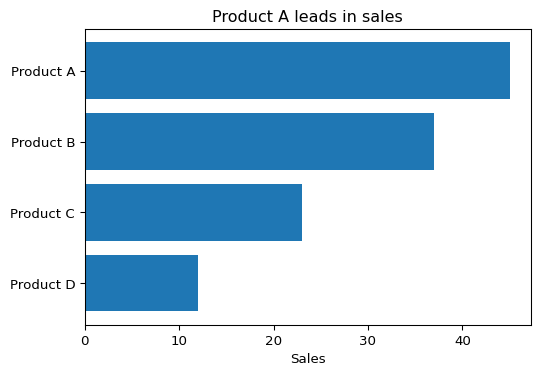

In [6]:
# horizontal bar chart (ranking)
categories = ["Product D", "Product C", "Product B", "Product A"]
values = [12, 23, 37, 45]

plt.figure(figsize=(6, 4))
plt.barh(categories, values)
plt.xlabel("Sales")
plt.title("Product A leads in sales")
plt.show()

Bar charts become even more useful when comparing multiple series side
by side, stacking them, or showing differences. To place two series next
to each other, shift the bar positions by the bar width using
`np.arange`.

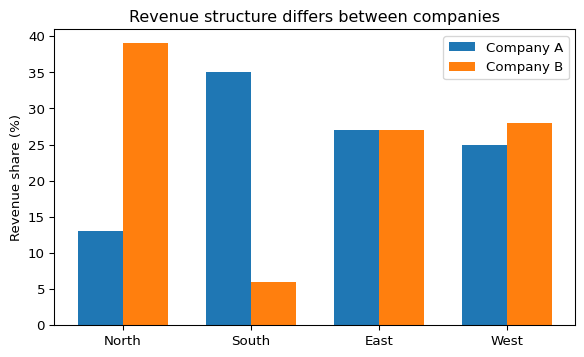

In [7]:
# grouped bar chart: two series side by side
regions = ["North", "South", "East", "West"]
company_a = [13, 35, 27, 25]
company_b = [39, 6, 27, 28]

x = np.arange(len(regions))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - width/2, company_a, width, label="Company A")
ax.bar(x + width/2, company_b, width, label="Company B")
ax.set_xticks(x)
ax.set_xticklabels(regions)
ax.set_ylabel("Revenue share (%)")
ax.set_title("Revenue structure differs between companies")
ax.legend()
plt.show()

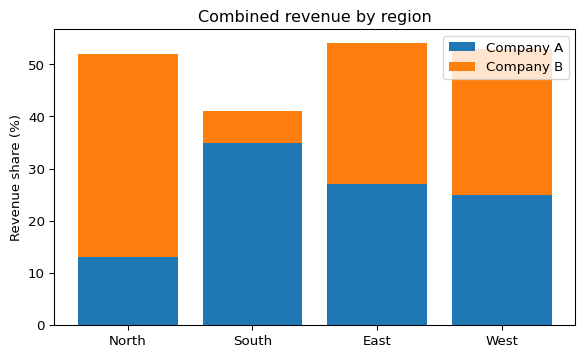

In [8]:
# stacked bar chart
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(regions, company_a, label="Company A")
ax.bar(regions, company_b, bottom=company_a, label="Company B")
ax.set_ylabel("Revenue share (%)")
ax.set_title("Combined revenue by region")
ax.legend()
plt.show()

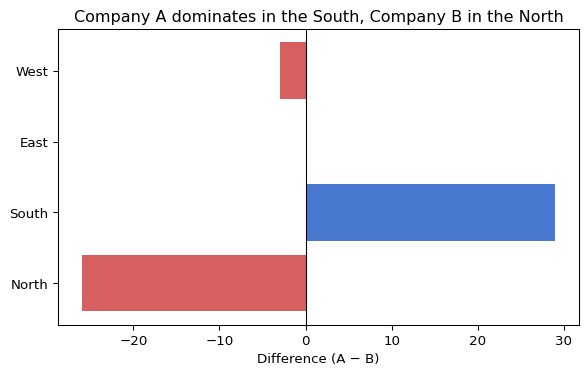

In [9]:
# difference chart: horizontal bars going left and right from a center axis
fig, ax = plt.subplots(figsize=(7, 4))
diff = [a - b for a, b in zip(company_a, company_b)]
colors = ["#4878cf" if d >= 0 else "#d65f5f" for d in diff]
ax.barh(regions, diff, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Difference (A − B)")
ax.set_title("Company A dominates in the South, Company B in the North")
plt.show()

## Histograms (`hist`)

A histogram groups numeric data into bins and shows the frequency or
density of each bin. It is the standard chart for **frequency
distributions**.

- `plt.hist(data, bins=..., density=...)`: histogram. Use `density=True`
  to normalize to a probability density.

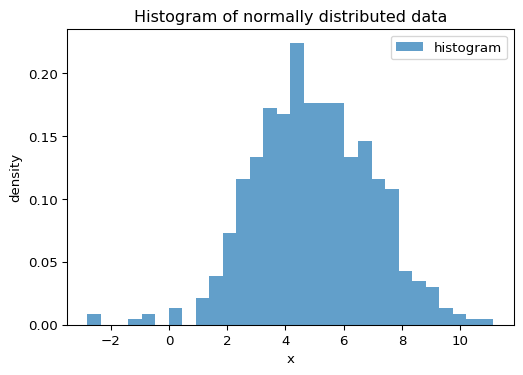

In [10]:
data = rng.normal(loc=5, scale=2, size=500)

plt.figure(figsize=(6, 4))
plt.hist(data, bins=30, density=True, alpha=0.7, label="histogram")
plt.xlabel("x")
plt.ylabel("density")
plt.title("Histogram of normally distributed data")
plt.legend()
plt.show()

## Box plots (`boxplot`)

A box plot summarizes the distribution of a dataset by showing the
median, quartiles, and outliers. It is useful for comparing
distributions across groups.

- `plt.boxplot(data_list)`: box plot. Pass a list of arrays to compare
  multiple groups.

/tmp/ipykernel_1214410/322536015.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_groups, labels=categories)

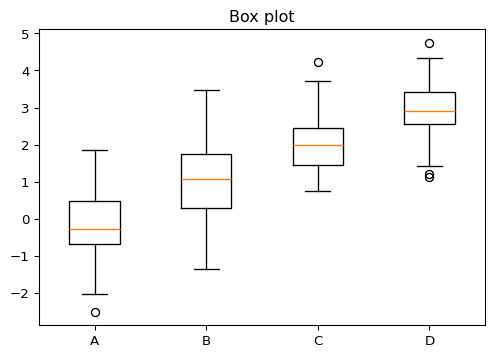

In [11]:
categories = ["A", "B", "C", "D"]
data_groups = [rng.normal(loc=m, size=50) for m in [0, 1, 2, 3]]

plt.figure(figsize=(6, 4))
plt.boxplot(data_groups, labels=categories)
plt.title("Box plot")
plt.show()

## Subplots (`subplots`)

Subplots allow placing multiple plots in a single figure. Each subplot
is an independent `axes` object.

- `fig, axes = plt.subplots(nrows, ncols, figsize=...)`: create a grid
  of subplots.
- `plt.tight_layout()`: automatically adjust spacing so labels do not
  overlap.

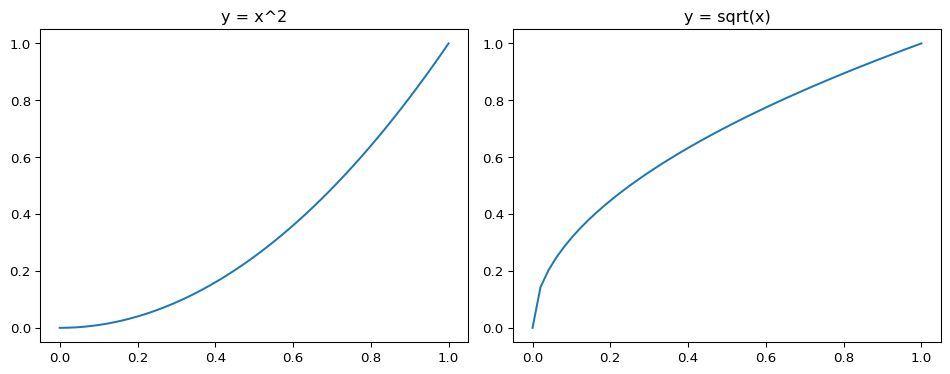

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(np.linspace(0, 1, 50), np.linspace(0, 1, 50)**2)
axes[0].set_title("y = x^2")

axes[1].plot(np.linspace(0, 1, 50), np.sqrt(np.linspace(0, 1, 50)))
axes[1].set_title("y = sqrt(x)")

plt.tight_layout()
plt.show()

## Heatmaps (`imshow`)

A heatmap displays a matrix of values as a grid of colored cells. It is
useful for visualizing correlation matrices, confusion matrices, or any
two-dimensional data where patterns emerge from color.

- `plt.imshow(matrix, cmap=...)`: display a matrix as a colored grid.
  Use `plt.colorbar()` to add a color legend.

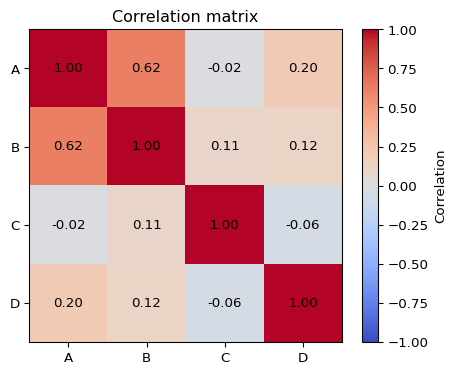

In [13]:
# heatmap of a correlation matrix
data = rng.normal(size=(100, 4))
data[:, 1] += 0.8 * data[:, 0]  # introduce correlation between columns 0 and 1
labels = ["A", "B", "C", "D"]
corr = np.corrcoef(data, rowvar=False)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(4))
ax.set_xticklabels(labels)
ax.set_yticks(range(4))
ax.set_yticklabels(labels)
# annotate each cell with the numeric value
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", fontsize=10)
fig.colorbar(im, label="Correlation")
ax.set_title("Correlation matrix")
plt.tight_layout()
plt.show()

## Error bar plots (`errorbar`)

An error bar plot shows data points together with their uncertainty —
for example, the mean of each group with the standard deviation or a
confidence interval. This is common in scientific and statistical
contexts.

- `plt.errorbar(x, y, yerr=...)`: plot data points with error bars
  (vertical by default; use `xerr` for horizontal).

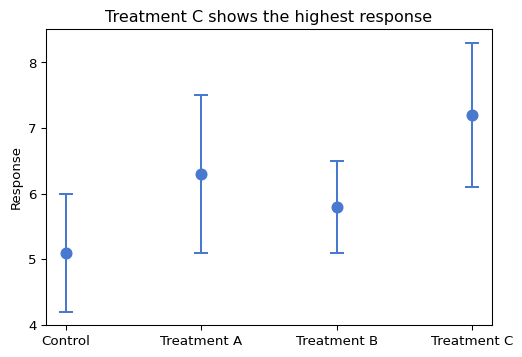

In [14]:
# error bar plot: group means with standard deviations
groups = ["Control", "Treatment A", "Treatment B", "Treatment C"]
means = [5.1, 6.3, 5.8, 7.2]
stds = [0.9, 1.2, 0.7, 1.1]

plt.figure(figsize=(6, 4))
plt.errorbar(groups, means, yerr=stds, fmt="o", capsize=5, capthick=1.5,
             markersize=8, color="#4878cf")
plt.ylabel("Response")
plt.title("Treatment C shows the highest response")
plt.show()

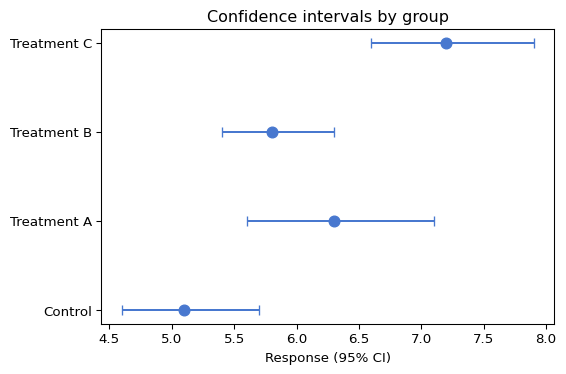

In [15]:
# horizontal error bars (e.g., confidence intervals)
fig, ax = plt.subplots(figsize=(6, 4))
y_pos = range(len(groups))
lower_err = [0.5, 0.7, 0.4, 0.6]
upper_err = [0.6, 0.8, 0.5, 0.7]
ax.errorbar(means, y_pos, xerr=[lower_err, upper_err], fmt="o", capsize=4,
            color="#4878cf", markersize=8)
ax.set_yticks(y_pos)
ax.set_yticklabels(groups)
ax.set_xlabel("Response (95% CI)")
ax.set_title("Confidence intervals by group")
plt.tight_layout()
plt.show()